Device: cuda


100%|██████████| 792M/792M [00:03<00:00, 245MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 115MB/s] 


Train: 2944 | Val: 736 | Test: 3669
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Epoch 1/10 | Train Loss: 0.5932, Acc: 0.6868 | Val Loss: 0.4917, Acc: 0.7649
Epoch 2/10 | Train Loss: 0.3582, Acc: 0.8325 | Val Loss: 0.4862, Acc: 0.7785
Epoch 3/10 | Train Loss: 0.2343, Acc: 0.8991 | Val Loss: 0.4887, Acc: 0.7948
Epoch 4/10 | Train Loss: 0.1898, Acc: 0.9243 | Val Loss: 0.6147, Acc: 0.7772
Epoch 5/10 | Train Loss: 0.1369, Acc: 0.9477 | Val Loss: 0.6043, Acc: 0.7948
Epoch 6/10 | Train Loss: 0.0998, Acc: 0.9616 | Val Loss: 0.6147, Acc: 0.7935
Epoch 7/10 | Train Loss: 0.1237, Acc: 0.9572 | Val Loss: 0.7289, Acc: 0.7976
Epoch 8/10 | Train Loss: 0.1078, Acc: 0.9586 | Val Loss: 0.6581, Acc: 0.8071
Epoch 9/10 | Train Loss: 0.1033, Acc: 0.9620 | Val Loss: 0.7338, Acc: 0.8030
Epoch 10/10 | Train Loss: 0.1202, Acc: 0.9596 | Val Loss: 0.6211, Acc: 0.8016
              precision    recall  f1-score   support

         Cat       0.80      0.83      0.81      1881
         Dog       0.81      0.78      0.79      1788

    accuracy                           0.80      3669
   macro av

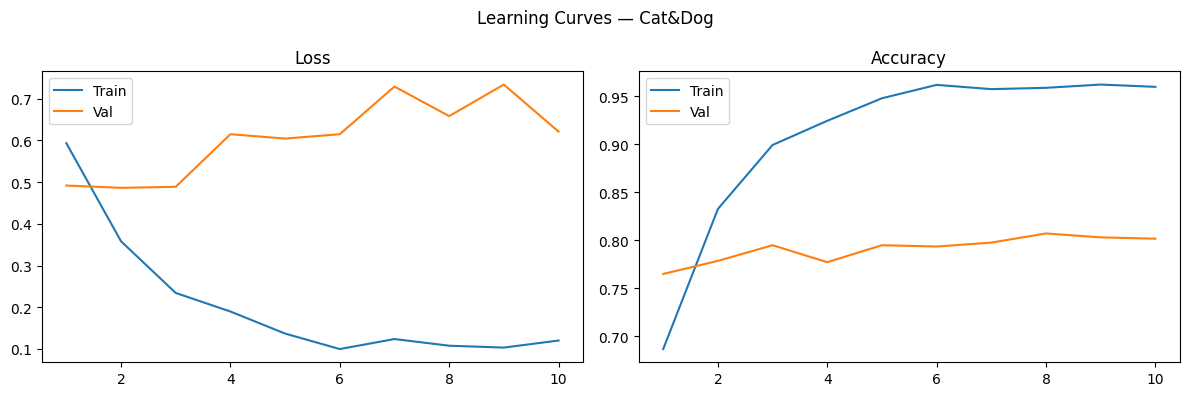

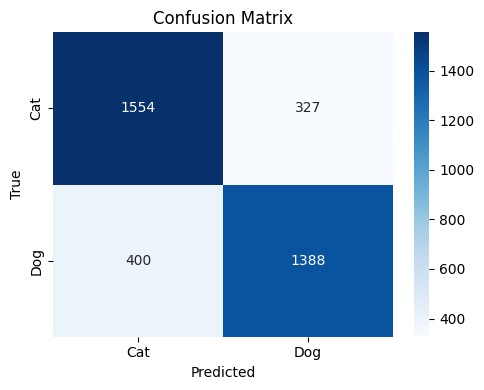

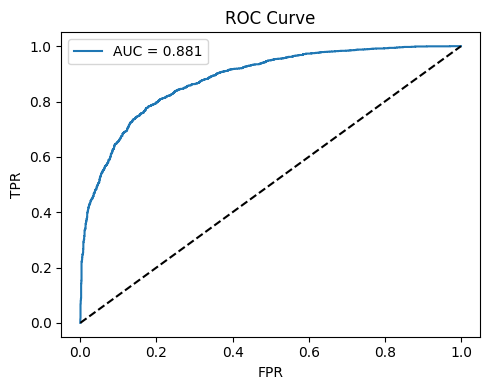

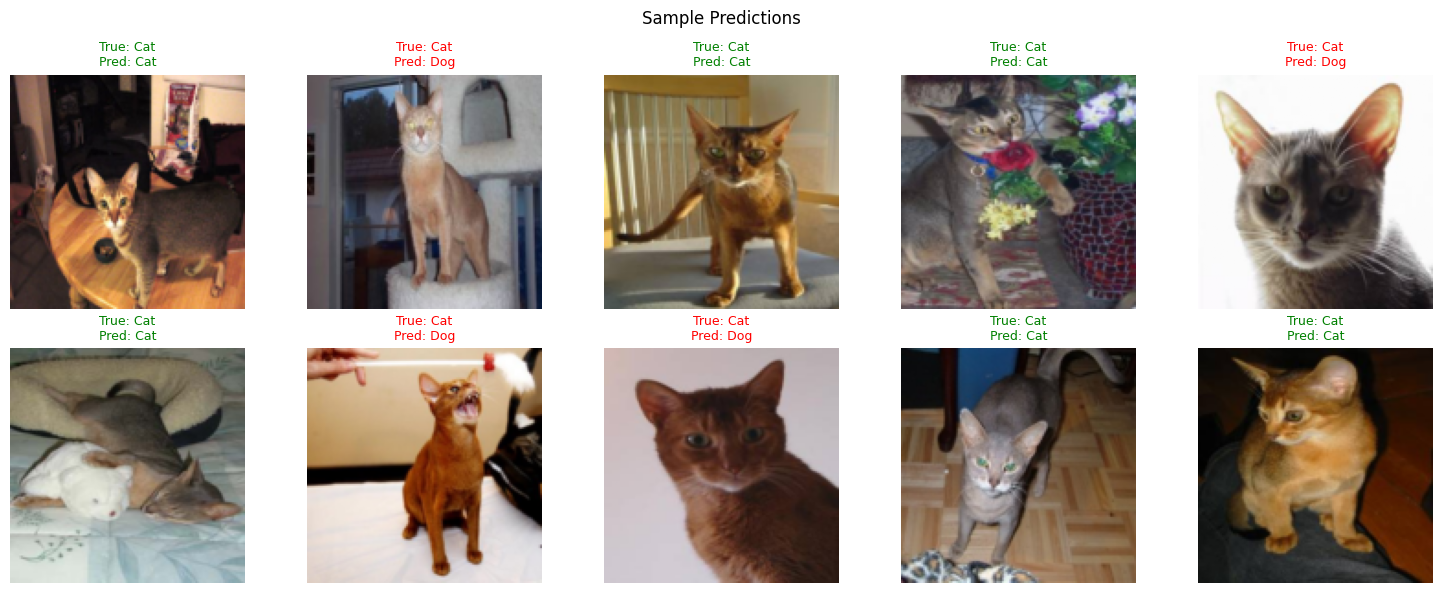

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://57a5cc6baeae9ef116.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
#!pip install torch torchvision gradio scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import gradio as gr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

#Dataset

transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

full_train = OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_train)
full_test  = OxfordIIITPet(root='./data', split='test',     download=True, transform=transform_test)

CAT_BREEDS = set(range(0, 19))

class BinaryPetsDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, 0 if label in CAT_BREEDS else 1

train_dataset = BinaryPetsDataset(full_train)
test_dataset  = BinaryPetsDataset(full_test)

val_size   = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_set, val_set = random_split(train_dataset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set,    batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,      batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_dataset)}")

#Model

model = models.resnet18(weights='ResNet18_Weights.DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 1e-3},
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-4}
])

#Training

NUM_EPOCHS = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc  = correct / total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

torch.save(model.state_dict(), 'cat_dog_model.pth')

#Evaluation

model.eval()
y_true, y_pred, y_proba = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_proba.extend(probs)

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_proba = np.array(y_proba)

print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))
print(f"Top-1 Error Rate: {(1 - np.mean(y_true == y_pred)) * 100:.2f}%")

#Plots

#Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'], label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.suptitle('Learning Curves — Cat&Dog')
plt.tight_layout()
plt.show()

#Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(); plt.tight_layout()
plt.show()

#Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_images, sample_labels = next(iter(test_loader))
with torch.no_grad():
    _, preds = torch.max(model(sample_images.to(device)), 1)

class_names = ['Cat', 'Dog']
for i, ax in enumerate(axes.flat):
    if i >= 10:
        break
    img = np.clip(sample_images[i].numpy().transpose(1, 2, 0) * 0.5 + 0.5, 0, 1)
    ax.imshow(img)
    true_l, pred_l = class_names[sample_labels[i]], class_names[preds[i].cpu()]
    ax.set_title(f'True: {true_l}\nPred: {pred_l}',
                 color='green' if true_l == pred_l else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Predictions')
plt.tight_layout()
plt.show()

#Gradio App

infer_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def predict(image):
    model.eval()
    img = infer_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1).cpu().numpy()[0]
    return {"Мяу": float(probs[0]), "Гав": float(probs[1])}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload a photo"),
    outputs=gr.Label(num_top_classes=2, label="Prediction"),
    title="Cat&Dog Classifier",
    description="Upload a photo - the model will classify it as a cat or a dog"
)

demo.launch(share=True)